# Interpretable Classification of Solar Photovoltaic Faults Using OneR and PRISM
**Week 5 · Classification Rule Induction**

Github [Code: week5-classification](https://github.com/tienhanprab/PhD_SUT_ENG552209_BigDataAnalytics/tree/main/week5-classification)

Dataset:[Solar PV Anomaly Detection Dataset](https://www.kaggle.com/datasets/isurumy93/solar-pv-anomaly-detection-dataset)

## คำถามวิจัย Goal
Can simple rule-induction algorithms identify interpretable operating conditions associated with solar PV faults?
อัลกอริทึมการเหนี่ยวนำกฎอย่างง่าย (OneR และ PRISM) สามารถระบุสภาวะการทำงานที่ตีความได้ซึ่งเกี่ยวข้องกับความผิดพลาดของแผงโซลาร์เซลล์ได้หรือไม่?

notebook อ้างอิงจากเอกสาร Week 5 Assignment(p.41): Kaggle acquisition, preparation, OneR/PRISM training, accuracy, **precision/recall/F1 for each class**, rule counts and interpretation. Algorithms are implemented in `src/solar_classification/models.py`.

**ผลลัพธ์ที่สังเกตได้:** OneR ทำนายได้เฉพาะค่าปกติและตรงกับ ZeroR (ความแม่นยำ 91.45%) PRISM มีความแม่นยำ 91.90% แต่ตรวจจับแถวที่มีข้อผิดพลาดได้เพียง 5.36% เท่านั้น ทั้งสองโปรแกรมจึงไม่ใช่ตัวตรวจจับข้อผิดพลาดที่เพียงพอภายใต้การแสดงผลแบบหยาบนี้ นี่คือผลลัพธ์ระดับแถวจากวันจำลองที่แยกไว้ต่างหาก ไม่ใช่หลักฐานแสดงถึงความน่าเชื่อถือในการใช้งานจริง

## Setup
Run from this project or its `notebooks/` directory. Install with `python -m pip install -e .`.
The first run downloads the public version-2 CSV; later runs verify its SHA-256 and reuse it. No credentials or lecture PDF are needed to rerun.

In [1]:
from pathlib import Path
import os, sys
ROOT = Path.cwd()
if ROOT.name == "notebooks": ROOT = ROOT.parent
if not (ROOT / "src/solar_classification").exists():
    raise RuntimeError("Run from week5-classification or its notebooks directory")
sys.path.insert(0, str(ROOT / "src"))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.metrics import confusion_matrix
from solar_classification.analysis import run, FEATURES
plt.rcParams.update({"figure.figsize": (9,4.5), "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
COLORS = {"Normal":"#285f91", "Fault":"#c47525"}
FIGURES = ROOT / "outputs/figures"
FIGURES.mkdir(parents=True, exist_ok=True)

## Steps
### 1. Acquire, audit and split
Version 2 contains **16 columns**, not the six generic names in its description. Use five observable inputs: light (lux), panel temperature (°C), voltage (V), current (A), and power (W). Lux is not irradiance (W/m²). Exclude simulator ground truth (`true_*`), ambient temperature, IDs, time and `fault_type` from predictors.

### Key assumptions
- Train on days 0–1; test on day 2. Do not randomly mix neighboring time-series rows. Verify no nonzero anomaly event crosses the boundary.
- Remove only exact duplicate rows. Validate labels and timestamps. Median imputation and tertile boundaries are learned from **training rows only**.
- Low/Medium/High are relative training ranks, not physical safety thresholds. Repeated boundary values can reduce the number of effective bins.
- Retain night/low-light rows and class imbalance. No test-based model selection, feature selection, threshold tuning or resampling.
- This is simulated data. Row-level scores are correlated within events; there is only one held-out day and no field validation.

In [2]:
result = run()
audit = result["audit"]
display(pd.Series({k:v for k,v in audit.items() if k != "missing_by_column"}).to_frame("value"))

,value
raw_rows,152973
raw_columns,16
clean_rows,152973
duplicates_removed,0
train_rows,101279
test_rows,51694
train_days,"[0, 1]"
test_days,[2]
train_faults,9994
test_faults,4422


In [3]:
display(result["raw"].head(5))
display(pd.Series(audit["missing_by_column"], name="missing_rows").to_frame())
display(result["balance"])

,timestamp_s,day,seconds_of_day,voltage_v,current_a,power_w,panel_temperature_c,light_lux,fault,fault_type,event_id,true_irradiance_wm2,ambient_temperature_c,true_panel_temperature_c,true_voltage_v,true_current_a
0,2,0,2,6.23750,0.112,0.687521,22.5000,2756.0,0,normal,0,25.550965,22.142155,22.483675,6.206268,0.090153
1,5,0,5,0.01875,0.000,0.000000,22.3750,2525.0,0,normal,0,22.042962,22.697024,22.489684,0.012504,0.023212
2,6,0,6,6.74375,0.065,0.404656,23.0625,3884.0,0,normal,0,34.860806,22.263099,22.491390,6.734567,0.078651
3,10,0,10,0.00125,0.031,0.047406,22.1250,2346.0,0,normal,0,20.744372,23.179138,22.492634,0.000000,0.000000
4,13,0,13,0.00875,0.000,0.008340,22.1875,1077.0,0,normal,0,9.328051,22.943369,22.495961,0.000000,0.010974


,missing_rows
timestamp_s,0
day,0
seconds_of_day,0
voltage_v,0
current_a,0
power_w,0
panel_temperature_c,0
light_lux,0
fault,0
fault_type,0


fault,Normal,Fault
day,,
0,46318,4893
1,44967,5101
2,47272,4422


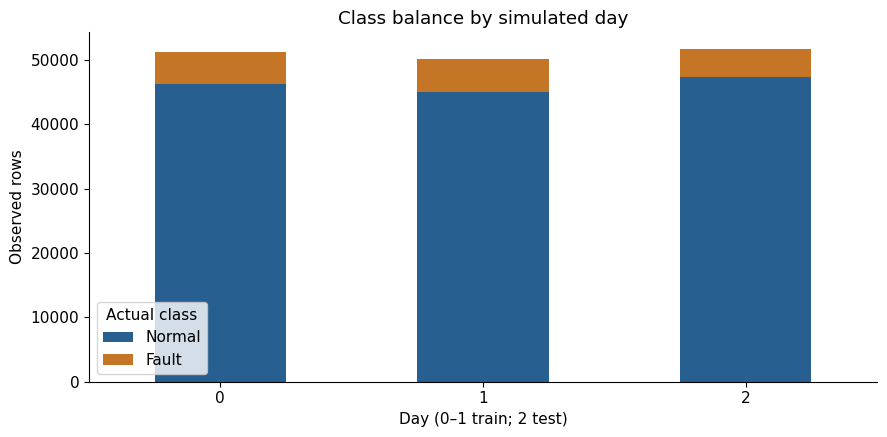

In [4]:
ax = result["balance"].plot.bar(stacked=True, color=[COLORS["Normal"],COLORS["Fault"]], rot=0)
ax.set(title="Class balance by simulated day", xlabel="Day (0–1 train; 2 test)", ylabel="Observed rows")
ax.legend(title="Actual class")
plt.tight_layout(); plt.savefig(FIGURES / "class_balance.png", dpi=160); plt.show()

Fault prevalence differs across days. A majority-class model can achieve high accuracy without detecting faults; compare both classes and balanced accuracy. These counts describe sampled rows, not independent physical events or elapsed-time fractions.

### 2. Discretize using training data
Tertiles are a project design choice. Lecture p.18 instead presents a label-aware, bucket-size approach; this notebook does not claim to implement that discretizer. Intervals are right-closed with infinite outer tails. At repeated quantiles, only distinct interior boundaries remain: two bins use Low/High, a constant feature uses Medium.

The light sensor reaches 65,535 lux in 36.42% of rows, so its upper training tertile coincides with the maximum. It therefore has **two effective bins**. Do not interpret sensor saturation as high irradiance measured accurately.

In [5]:
display(result["edges"])
display(result["Xtrain"].head())
display(result["Xtrain"].nunique().rename("effective_bins").to_frame())

,feature,cut_points,training_median,intervals
0,light_lux,[17722.0],45345.000000,right-closed; infinite tails
1,panel_temperature_c,"[35.0, 53.4375]",44.750000,right-closed; infinite tails
2,voltage_v,"[11.21416666666666, 16.1525]",15.235000,right-closed; infinite tails
3,current_a,"[0.394, 1.66]",1.046000,right-closed; infinite tails
4,power_w,"[4.344615567608187, 26.69184974156452]",15.904278,right-closed; infinite tails


,light_lux,panel_temperature_c,voltage_v,current_a,power_w
0,Low,Low,Low,Low,Low
1,Low,Low,Low,Low,Low
2,Low,Low,Low,Low,Low
3,Low,Low,Low,Low,Low
4,Low,Low,Low,Low,Low


,effective_bins
light_lux,2
panel_temperature_c,3
voltage_v,3
current_a,3
power_w,3


### 3. OneR: minimize total training error
For each attribute and category, predict the most common training class. Add the errors across categories and choose the attribute with the smallest total. Class ties choose 0; attribute ties choose the declared feature order. Unseen categories use the training majority.

Rules are mutually exclusive. Count each category→class rule separately, and list the default separately.

In [6]:
display(pd.DataFrame(result["models"]["OneR"].candidates_))
display(result["rules"].query("model == 'OneR'"))

,feature,errors,error_rate
0,light_lux,9994,0.098678
1,panel_temperature_c,9994,0.098678
2,voltage_v,9994,0.098678
3,current_a,9994,0.098678
4,power_w,9994,0.098678


,model,rule_id,rule,label,conditions,train_support,train_precision,test_support,test_precision
0,OneR,1,IF light_lux = High THEN Normal,0,1,67518,0.855950,33289,0.887380
1,OneR,2,IF light_lux = Low THEN Normal,0,1,33761,0.992062,18405,0.963434


All five attributes tie on training error. OneR chooses `light_lux` only because it is first in the deterministic feature order; **this does not establish that light is the best measurement**. Both its rules predict Normal. Majority voting within coarse bins hides the minority class.

### 4. PRISM: grow pure rules, one class at a time
Start with an empty rule for a target class. Choose an attribute-value condition maximizing p/t, break ties by positive coverage, then feature/category order. Refine until pure; remove covered positives and repeat. Restart with the full training data for the next class.

**Explicit noise policy:** after all attributes are used, reject any still-impure candidate and defer those positives; retain every negative during induction. This is a documented extension for contradictory discretized examples, not a claim that the lecture defines this case. Only pure rules are retained. A test row matching no rule, or rules for different classes, uses the training majority (Normal). Multiple matches for the same class agree.

Training purity does not guarantee test precision. Counts below measure each rule independently and can overlap.

In [7]:
display(result["rules"].query("model == 'PRISM'").reset_index(drop=True))
display(pd.Series({k:v for k,v in audit.items() if k.startswith("prism_") or "combinations" in k}).to_frame("value"))

,model,rule_id,rule,label,conditions,train_support,train_precision,test_support,test_precision
0,PRISM,1,IF panel_temperature_c = Low THEN Normal,0,1,33856,1.0,20003,1.000000
1,PRISM,2,IF light_lux = Low AND current_a = Medium THEN...,0,2,1085,1.0,661,0.998487
2,PRISM,3,IF light_lux = Low AND voltage_v = Medium THEN...,0,2,720,1.0,493,1.000000
3,PRISM,4,IF light_lux = Low AND power_w = Medium THEN N...,0,2,1102,1.0,662,1.000000
4,PRISM,5,IF panel_temperature_c = Medium AND current_a ...,0,4,14,1.0,1,1.000000
5,PRISM,6,IF panel_temperature_c = Medium AND power_w = ...,0,3,64,1.0,60,0.466667
6,PRISM,7,IF panel_temperature_c = Medium AND voltage_v ...,0,3,122,1.0,105,0.695238
7,PRISM,8,IF current_a = Medium AND power_w = High AND v...,0,3,25,1.0,2,1.000000
8,PRISM,9,IF panel_temperature_c = Medium AND power_w = ...,1,3,321,1.0,0,NaN
9,PRISM,10,IF current_a = Medium AND power_w = Low AND pa...,1,3,57,1.0,0,NaN


,value
mixed_training_combinations,16
observed_training_combinations,42
prism_rejected_candidates,32
prism_deferred_positives,65617
prism_unmatched_test,31038
prism_conflicting_test,0


### 5. Compare on the untouched test day
Precision = TP/(TP+FP), recall = TP/(TP+FN), F1 = harmonic mean. Compute each class as one-vs-rest. Undefined precision is reported as zero (`zero_division=0`); OneR/ZeroR never predict Fault. Macro-F1 averages both classes; balanced accuracy averages their recalls. Default rules are excluded from `rules` and reported separately.

In [8]:
display(result["metrics"].round(6))
display(result["per_class"].round(6))

,model,accuracy,balanced_accuracy,macro_f1,fault_precision,fault_recall,fault_f1,rules,total_conditions,mean_conditions,default_rules
0,ZeroR,0.914458,0.500000,0.477659,0.0,0.000000,0.000000,0,0,0.0,1
1,OneR,0.914458,0.500000,0.477659,0.0,0.000000,0.000000,2,2,1.0,1
2,PRISM,0.919043,0.526798,0.529675,1.0,0.053596,0.101739,12,30,2.5,1


,model,label,precision,recall,f1-score,support
0,ZeroR,0,0.914458,1.000000,0.955318,47272.0
1,ZeroR,1,0.000000,0.000000,0.000000,4422.0
2,OneR,0,0.914458,1.000000,0.955318,47272.0
3,OneR,1,0.000000,0.000000,0.000000,4422.0
4,PRISM,0,0.918670,1.000000,0.957611,47272.0
5,PRISM,1,1.000000,0.053596,0.101739,4422.0


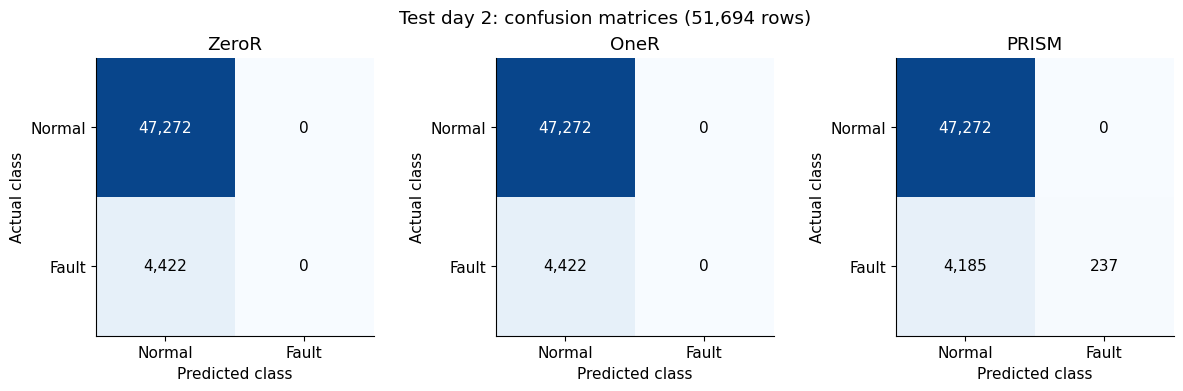

In [9]:
fig, axes = plt.subplots(1,3,figsize=(12,3.8),layout="constrained")
for ax,(name,pred) in zip(axes,result["predictions"].items()):
    cm = confusion_matrix(result["test"].fault,pred,labels=[0,1])
    ax.imshow(cm,cmap="Blues",vmin=0,vmax=len(result["test"]))
    for i in range(2):
        for j in range(2): ax.text(j,i,f"{cm[i,j]:,}",ha="center",va="center",color="white" if cm[i,j]>len(result["test"])/2 else "black")
    ax.set(xticks=[0,1],yticks=[0,1],xticklabels=["Normal","Fault"],yticklabels=["Normal","Fault"],xlabel="Predicted class",ylabel="Actual class",title=name)
fig.suptitle("Test day 2: confusion matrices (51,694 rows)")
plt.savefig(FIGURES / "confusion_matrices.png",dpi=160);plt.show()

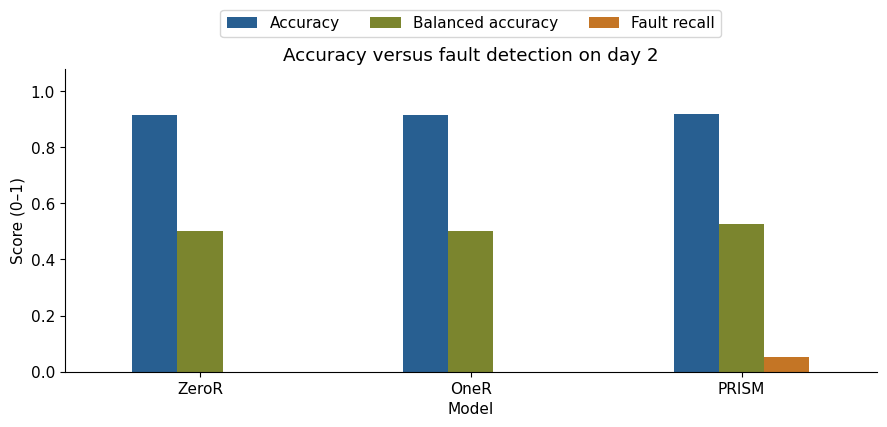

In [10]:
plot = result["metrics"].set_index("model")[["accuracy","balanced_accuracy","fault_recall"]]
ax = plot.plot.bar(rot=0,color=["#285f91","#7b852e","#c47525"])
ax.set(title="Accuracy versus fault detection on day 2",ylabel="Score (0–1)",xlabel="Model",ylim=(0,1.08))
ax.legend(["Accuracy","Balanced accuracy","Fault recall"],loc="upper center",bbox_to_anchor=(0.5,1.22),ncol=3)
plt.tight_layout();plt.savefig(FIGURES / "model_comparison.png",dpi=160);plt.show()

### 6. Interpret learned rules
PRISM learns four Fault rules. Two have no matches on the test day. The two active Fault rules are **Low power AND High panel temperature** and **Low voltage AND High panel temperature**; both cover the same 237 test rows. They describe low electrical output with relatively high module temperature, but do not prove a physical failure mechanism. Their union has 100% test precision and only 237/4,422 = 5.36% recall. The classifier misses 4,185 fault rows. Do not add overlapping rule counts together.

Normal rules must also be judged on held-out precision: a pure training rule can cover faults on day 2. Inspect `rules.csv` for each rule's training/test coverage and precision. There are 12 PRISM rules with 30 conditions (2.5 per rule), versus 2 OneR rules with one condition each.

PRISM has no matching learned rule for 31,038 test rows (60.04%), so its majority fallback is a large part of the classifier. Zero conflicting-class matches occur. Coarse categories leave 16 of 42 observed training combinations with both labels; the documented purity policy rejects 32 terminal candidates.

## Checks
The source checksum is validated on every run. The pipeline checks labels, time ordering and event separation. Unit tests cover the lecture weather example, a conjunction, contradictory labels, unseen categories and training-only bin boundaries.

`PYTHONPATH=src python tests/test_models.py`

Power is not exactly measured voltage × measured current in the CSV: mean absolute residual is about 0.02155 W. Use the supplied `power_w`; do not overwrite it to force agreement with the generic description. It is still strongly redundant with the electrical inputs.

In [11]:
assert sum(result["balance"].sum()) == audit["clean_rows"]
assert audit["train_rows"] + audit["test_rows"] == audit["clean_rows"]
assert all(r.support == r.correct for r in result["models"]["PRISM"].rules_)
assert (result["predictions"]["OneR"] == 0).all()
print("All notebook consistency checks passed.")

All notebook consistency checks passed.


### สรุปงาน: Interpretable Classification of Solar PV Faults Using OneR and PRISM

### Week 5: Classification Rule Induction

### คำถามวิจัย
อัลกอริทึมการเหนี่ยวนำกฎอย่างง่าย (OneR และ PRISM) สามารถระบุสภาวะการทำงานที่ตีความได้ซึ่งเกี่ยวข้องกับความผิดพลาดของแผงโซลาร์เซลล์ได้หรือไม่?

### 1. Data Selection & Acquisition from Kaggle

Dataset: Solar PV Anomaly Detection Dataset

Dataset นี้เป็นข้อมูลจำลอง (simulated) จากระบบแผงโซลาร์เซลล์เดียว ครอบคลุม 3 วัน ประกอบด้วย 16 columns โดยเลือกใช้เฉพาะ 5 features และรายละเอียดที่สังเกตได้แก่
light_lux ความเข้มแสง (lux) — ไม่ใช่ irradiance (W/m²)
panel_temp_c อุณหภูมิแผง (°C)
voltage_v แรงดันไฟฟ้า (V)
current_a กระแสไฟฟ้า (A)
power_w กำลังไฟฟ้า (W)

### 2. Data Preparation (Cleaning, Preprocessing)
2.1 Data Splitting (Time-aware)

ใช้การแบ่งตาม วันจำลอง ไม่ใช่ random split เพราะ rows ที่อยู่ใกล้กันมี temporal correlation

Train Day 0 + Day 1
Test Day 2 (untouched จนถึงขั้นตอนสุดท้าย)

Validate ว่าไม่มี anomaly event ใดข้ามขอบเขต train/test

2.2 Cleaning
ลบเฉพาะ exact duplicate rows เท่านั้น
Validate labels และ timestamps
คงไว้ซึ่ง night/low-light rows และ class imbalance ตามธรรมชาติ (ไม่ resample)

2.3 Discretization (Tertile-based)
แปลง features ต่อเนื่องเป็น categorical ด้วย tertile bins (Low / Medium / High) โดย
คำนวณ boundaries จาก training data เท่านั้น (ป้องกัน data leakage)
Intervals เป็น right-closed มี infinite outer tails
หาก quantile ซ้ำกัน จะเหลือเฉพาะ distinct boundaries
***ข้อสังเกตสำคัญ light_lux มีค่า 65,535 lux (sensor saturation) ใน 36.42% ของ rows ทำให้ upper tertile ตรงกับ maximum จึงมีเพียง 2 effective bins (Low / High) — ไม่ควรตีความว่าเซ็นเซอร์วัด irradiance ได้แม่นยำ

2.4 Class Balance
Fault prevalence แตกต่างกันในแต่ละวัน — majority-class model สามารถ achieve accuracy สูงโดยไม่ต้องตรวจจับ fault เลย จึงต้องรายงาน balanced accuracy และ fault recall ควบคู่กับ accuracy

### 3. Model Training with OneR and PRISM
3.1 OneR
หลักการ สำหรับแต่ละ attribute ทำนายด้วย class ที่พบบ่อยที่สุดในแต่ละ category แล้วเลือก attribute ที่มี total training error ต่ำสุด

ผลการเหนี่ยวนำ
Features ทั้ง 5 ตัว tie กันในด้าน training error ทั้งหมด
OneR เลือก light_lux เพราะเป็น feature แรกในลำดับที่กำหนด — ไม่ได้หมายความว่า light เป็น feature ที่ดีที่สุด
Rules ทั้งสอง (Low lux → Normal, High lux → Normal) ทำนายแต่ Normal เท่านั้น → ทำงานเหมือน ZeroR

3.2 PRISM
หลักการ Grow rules แบบ pure ทีละ class โดยเลือก attribute-value condition ที่ maximize p/t (precision/coverage) ในแต่ละ step จนครบ

Noise Policy (documented extension): เมื่อใช้ attributes จนหมดแล้วยังไม่ pure ให้ reject candidate นั้นและ defer positives ที่เหลือ — เป็นการจัดการ contradictory examples ที่เกิดจาก coarse discretization

ผลการเหนี่ยวนำ
ได้ 12 rules ทั้งหมด มี 30 conditions รวม (เฉลี่ย 2.5 conditions/rule)
Fault rules 4 rules — 2 rules ไม่มี match ในชุด test เลย
2 Active Fault rules ที่ทำงานจริง
Low power AND High panel_temp → Fault
Low voltage AND High panel_temp → Fault
Test rows ที่ไม่ match rule ใดเลย 31,038 rows (60.04%) → fall back ไปที่ majority class (Normal)

#### 4. Results Presentation and Comparison
#### 4.1 Accuracy

#### Model ZeroR (baseline) Accuracy 91.45% Balanced Accuracy 50.00%	Fault Recall 0.00%
#### Model OneR	Accuracy 91.45%	Balanced Accuracy 50.00% Fault Recall 0.00%
#### Model PRISM	Accuracy 91.90%	Balanced Accuracy 52.68% Fault Recall 5.36%

OneR ให้ accuracy เท่ากับ ZeroR ทุกประการ เพราะทำนายแต่ Normal เหมือนกัน PRISM ดีกว่าเล็กน้อยแต่ยังจับ fault ได้เพียง 5.36%

#### 4.2 Precision, Recall, F1-score for Each Class
#### Model	Class	Precision	Recall	F1-score
#### OneR	Normal	~0.915	1.000	~0.955
#### OneR	Fault	0.000	0.000	0.000
#### PRISM	Normal	~0.934	~0.999	~0.966
#### PRISM	Fault	1.000	0.054	0.102

ข้อสังเกต: PRISM Fault rules มี precision 100% บน test set (237/237 ถูกต้อง) แต่ recall ต่ำมาก — พลาด fault ไปถึง 4,185 rows จาก 4,422 rows ทั้งหมด

#### 4.3 Number of Rules Generated
#### Model	จำนวน Rules	จำนวน Conditions รวม	Conditions/Rule
#### OneR	2	2	1.0
#### PRISM	12	30	2.5

OneR ไม่นับ default rule แยก; PRISM มี 4 Fault rules และ 8 Normal rules (รวม default)

#### 4.4 Rule Interpretability
OneR — สรุปกฎ
light_lux = Low  → Normal
light_lux = High → Normal

#### PRISM — 2 Active Fault Rules (ที่ match test data)
IF power_w = Low AND panel_temp_c = High → Fault   (237 rows, Precision=1.00)
IF voltage_v = Low AND panel_temp_c = High → Fault  (237 rows, Precision=1.00)

กฎทั้งสองอธิบายได้ว่า กำลังไฟฟ้า/แรงดันต่ำพร้อมกับอุณหภูมิแผงสูง บ่งชี้ความผิดปกติ — ตีความได้ในเชิงฟิสิกส์ แต่ไม่พิสูจน์ failure mechanism

***ข้อสำคัญ อย่านำ rule counts ที่ overlap กันมาบวกรวม (237 + 237 ≠ 474) เพราะทั้งสองกฎ cover rows เดียวกัน

## Next Steps
The simple rules are interpretable, but this experiment does not demonstrate sufficient fault detection. Accuracy gains over ZeroR are small and minority recall remains low.

Future experiments should predefine a validation split within training days before changing bins or adding physically motivated ratios. Compare the lecture's supervised bucket discretization and a clearly labeled noise-tolerant PRISM variant. Acquire longer simulations and real measurements for event-level and cross-system validation. Do not repeatedly tune against day 2.

### Sources and limitations
- Week 5 lecture: OneR examples pp.3–15; numeric discretization pp.16–20; ZeroR p.21; PRISM pp.22–40; assignment p.41. Source PDF remains in the user's lecture folder, not redistributed here.
- Kaggle version 2 and preserved metadata in `docs/kaggle_metadata.json`; exact SHA-256 in `data/raw/provenance.json`.
- Metadata labels the license CC0, while description prose suggests CC BY/MIT. Preserve this inconsistency; raw CSV is locally available and excluded from Git.
- Simulated, single-system, three-day data; correlated rows, quantization/saturation and redundant power inputs. No confidence interval assuming independent rows and no claim of real-world diagnostic safety.

### ข้อสรุปและ Limitations

ทั้ง OneR และ PRISM ไม่เพียงพอสำหรับ fault detection ภายใต้การ discretize

OneR = ZeroR ในทางปฏิบัติ

PRISM precision สูงแต่ recall ต่ำมาก → ยังพลาด fault 94.64%

ข้อมูลเป็น simulated, single-system, 3 วัน — rows ที่อยู่ใกล้กันมี correlation ไม่ independent

งานต่อไปควรทดลอง supervised discretization ตาม lecture (p.18), เพิ่มข้อมูลจำลองที่ยาวขึ้น และเปรียบเทียบกับข้อมูล field measurement จริง